# TP4 - Validation et Cohérence des Données

**Difficulté:** Intermédiaire  
**Dataset:** healthcare_inconsistent.csv  
**Description:** Vérification des contraintes logiques et cohérence inter-colonnes

---


## Imports des Bibliothèques


In [1195]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [1196]:
# Charger le dataset
df = pd.read_csv('healthcare_inconsistent.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 300 lignes × 9 colonnes
 Taille mémoire: 0.08 MB




,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          300 non-null    int64  
 2   birth_date   300 non-null    object 
 3   email        300 non-null    object 
 4   start_date   300 non-null    object 
 5   end_date     300 non-null    object 
 6   price        300 non-null    float64
 7   postal_code  300 non-null    int64  
 8   heart_rate   300 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 21.2+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

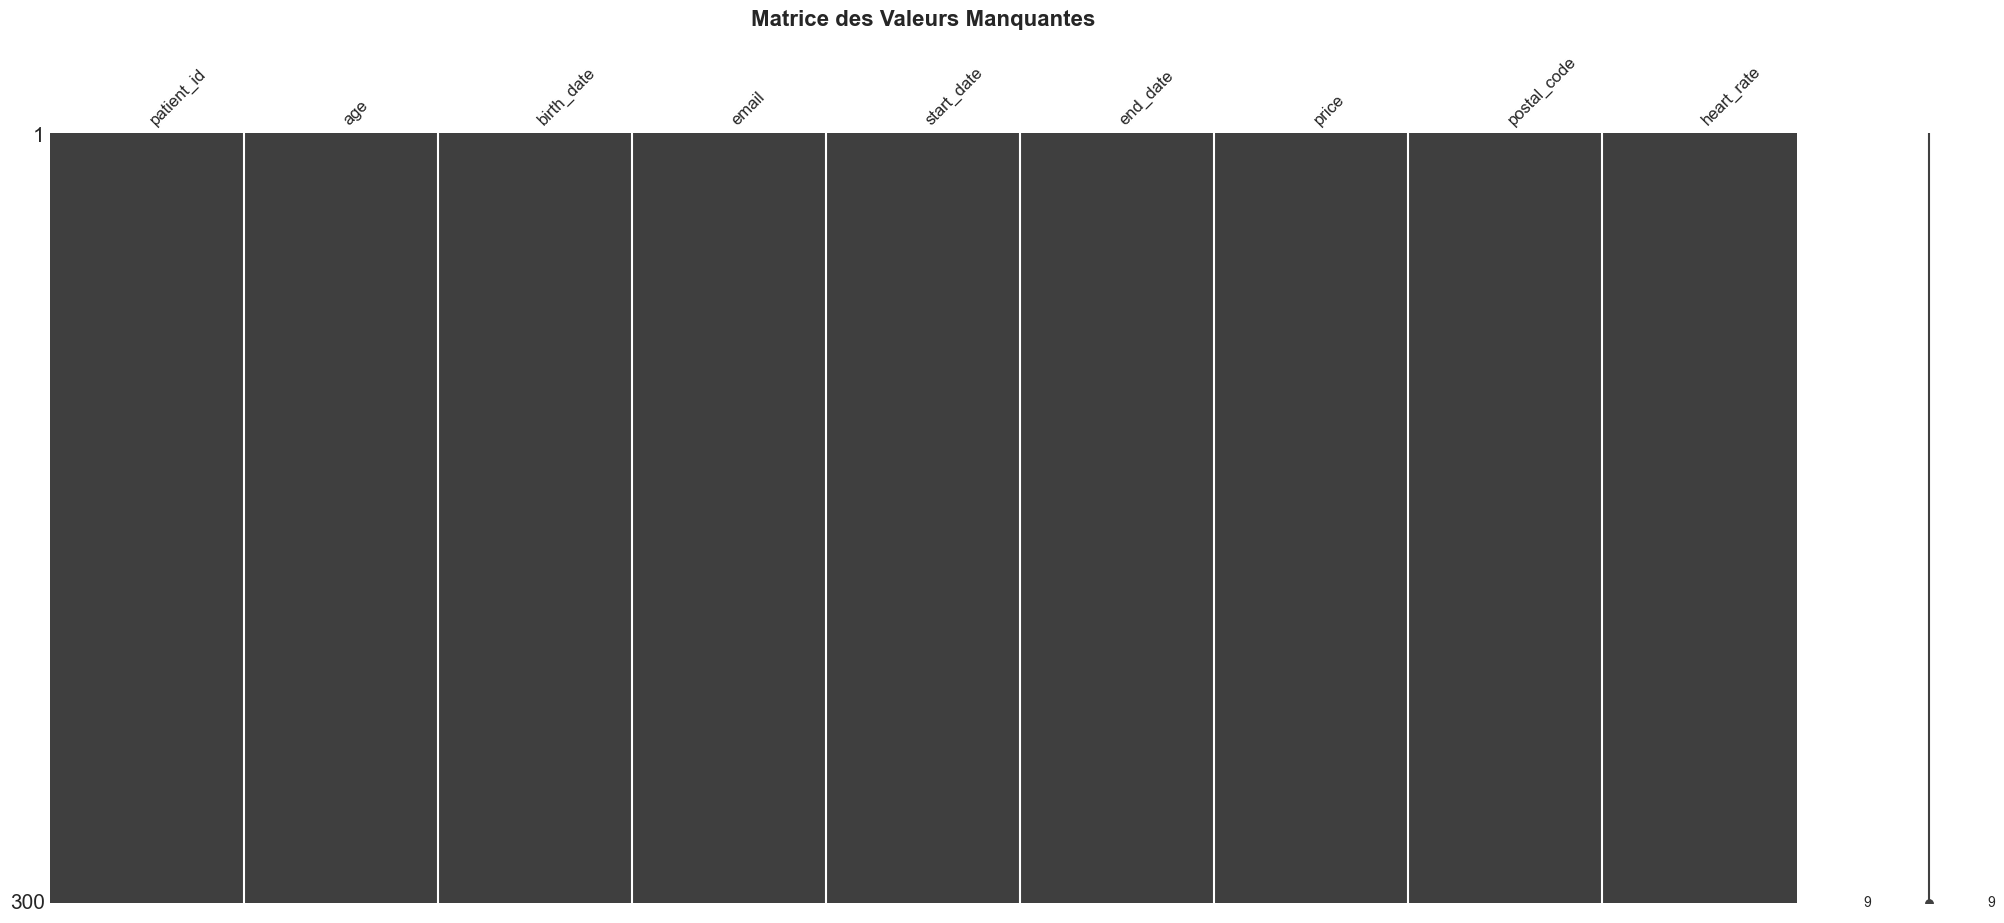


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [1197]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?
2. Les dates de fin sont-elles toujours après les dates de début ?
3. Y a-t-il des emails sans '@' ?
4. Les codes postaux respectent-ils le format attendu ?
5. Y a-t-il des incohérences entre l'âge et la date de naissance ?
6. Les prix sont-ils tous positifs ?
7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?
8. Les unités de mesure sont-elles cohérentes ?
9. Combien d'enregistrements violent au moins une contrainte ?
10. Quelle contrainte est la plus souvent violée ?


In [1198]:
# 1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?

df['age'].value_counts()

age
-5     10
 44     9
 17     7
 24     6
 5      6
       ..
 9      1
 80     1
 4      1
 1      1
 60     1
Name: count, Length: 112, dtype: int64

In [1199]:
# 2. Les dates de fin sont-elles toujours après les dates de début ?

result = df['start_date'] < df['end_date']
print(result.value_counts())

True     295
False      5
Name: count, dtype: int64


In [1200]:
# 3. Y a-t-il des emails sans '@' ?

df['email'].head()

0    wlmit@company.com
1        invalid-email
2    wkimx@company.com
3      krvzm@gmail.com
4      dzicv@gmail.com
Name: email, dtype: object

In [1201]:
# 4. Les codes postaux respectent-ils le format attendu ?

df['postal_code'].sample(5)

255    6828
282    2056
148    6241
274    3141
299    3831
Name: postal_code, dtype: int64

In [1202]:
# 5. Y a-t-il des incohérences entre l'âge et la date de naissance ?

df['birth_date'].sample(5)

print("Oui, ils sont tous nés en 1920")

Oui, ils sont tous nés en 1920


In [1203]:
# 6. Les prix sont-ils tous positifs ?

prix_pos = df['price'] > 0
print(prix_pos.value_counts()) 

price
True     294
False      6
Name: count, dtype: int64


In [1204]:
# 7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?

df['heart_rate'].describe()

# Oui les valeurs dépassent 220, ce qui n'est pas correct

count   300.00
mean    136.68
std      62.92
min      30.00
25%      79.75
50%     137.00
75%     186.00
max     249.00
Name: heart_rate, dtype: float64

In [1205]:
# 8. Les unités de mesure sont-elles cohérentes ?

# Non

In [1206]:
# 9. Combien d'enregistrements violent au moins une contrainte ?

# Tous les enregistrements car la birth_date est mauvaise

In [1207]:
# 10. Quelle contrainte est la plus souvent violée ?

# birth_date

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Définir un dictionnaire de contraintes de validation
### Étape 2: Créer une fonction validate_constraints(df)
### Étape 3: Valider les plages numériques (âge, prix, etc.)
### Étape 4: Valider les formats (email, téléphone, code postal)
### Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
### Étape 6: Créer des indicateurs pour chaque violation
### Étape 7: Décider des actions correctives pour chaque type
### Étape 8: Appliquer les corrections
### Étape 9: Standardiser les unités de mesure
### Étape 10: Générer un rapport de validation complet


In [1208]:
df.head()

,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119


In [1209]:
# ========================================
# Étape 1: Définir un dictionnaire de contraintes de validation
# ========================================

# TODO: Écrivez votre code ici

contraints = {"patient_id" : {"type" : int, "unique" : True},
              "age" : {"type" : int, "min" : 0, "max" : 120},
              "birth_date" : {"type" : str, "pattern" : r"^\d{4}-\d{2}-\d{2}$" },
              "email" : {"type" : str, "pattern": r"^[\w\.-]+@[\w\.-]+\.\w+$" },
              "start_date" : {"type" : str, "pattern": r"^\d{4}-\d{2}-\d{2}$"},
              "end_date" : {"type" : str, "pattern": r"^\d{4}-\d{2}-\d{2}$"},
              "price" : {"type" : float, "min" : 0.0},
              "postal_code" : {"type" : str, "pattern" : r"^\d{5}$" },             # 5 chiffres pour la France
              "heart_rate" : {"type" : int, "min" : 30, "max" : 220}
              }


# Vérification
print(f" Étape 1 complétée")

 Étape 1 complétée


In [1210]:
# ========================================
# Étape 2: Créer une fonction validate_constraints(df)
# ========================================

# TODO: Écrivez votre code ici

# Définir les règles de validation
def validate_constraints(df):
    errors = []

    # Contrainte 1: Date de fin après date de début
    if 'start_date' in df.columns and 'end_date' in df.columns:
        invalid = df[df['end_date'] < df['start_date']]
        if len(invalid) > 0:
            errors.append(f"Dates incohérentes : {len(invalid)} lignes")

    # Contrainte 2: Age entre 0 et 120
    if 'age' in df.columns:
        invalid = df[(df['age'] < 0) | (df['age'] > 120)]
        if len(invalid) > 0:
            errors.append(f"Ages invalides : {len(invalid)} lignes")

    # Contrainte 3: Prix positifs
    price_cols = [col for col in df.columns if 'price' in col.lower()]
    for col in price_cols:
        invalid = df[df[col] < 0]
        if len(invalid) > 0:
            errors.append(f"Prix négatifs : {len(invalid)} lignes")

    # Contrainte 4: Emails valides
    if 'email' in df.columns:
        email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
        invalid = df[~df['email'].str.match(email_pattern, na=False)]
        if len(invalid) > 0:
            errors.append(f"Emails invalides : {len(invalid)} lignes")


    # Contrainte 5 : Heart rate entre 30 et 220 bpm
    if 'heart_rate' in df.columns:
        invalid = df[(df['heart_rate'] < 30) | (df['heart_rate'] > 220)]
        if len(invalid) > 0:
            errors.append(f"Rythmes cardiaques invalides : {len(invalid)} lignes")


    # Contrainte 6 : Code postal valide
    if 'postal_code' in df.columns:
        invalid = df[(df['postal_code'].astype(str).str.len() != 5)]
        if len(invalid) > 0:
            errors.append(f"Codes postaux invalides : {len(invalid)} lignes")


    return errors

# Verification
errors = validate_constraints(df)
for error in errors:
    print(f"{error}")


# Vérification
print(f" Étape 2 complétée")

Dates incohérentes : 5 lignes
Ages invalides : 10 lignes
Prix négatifs : 6 lignes
Emails invalides : 8 lignes
Rythmes cardiaques invalides : 34 lignes
Codes postaux invalides : 300 lignes
 Étape 2 complétée


In [1211]:
# ========================================
# Étape 3: Valider les plages numériques (âge, prix, etc.)
# ========================================

# TODO: Écrivez votre code ici

valid_age =  (df['age'] < 0) | (df['age'] > 120)
print(f"Nombres d'âge non valide : {valid_age.value_counts()[1]}")

valid_price =  df['price'] > 0
print(f"Nombres de prix non valide : {valid_price.value_counts()[1]}")

valid_heart_rate = (df['heart_rate'] < 30) | (df['heart_rate'] > 220)
print(f"Nombres de rythmes cardiaques non valides : {valid_heart_rate.value_counts().get(True, 0)}")


# Vérification
print(f" Étape 3 complétée")

Nombres d'âge non valide : 10
Nombres de prix non valide : 6
Nombres de rythmes cardiaques non valides : 34
 Étape 3 complétée


In [1212]:
# ========================================
# Étape 4: Valider les formats (email, téléphone, code postal)
# ========================================

# TODO: Écrivez votre code ici

email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
valid_email = df[~df['email'].str.match(email_pattern, na=False)]
valid_email


,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
7,8,27,1920-01-08,invalid-email,2023-01-08,2023-01-12,4549.80,4490,155
9,10,58,1920-01-10,invalid-email,2023-01-10,2023-01-14,2512.30,7745,238
123,124,104,1920-05-03,invalid-email,2023-05-04,2023-05-08,1029.74,9185,160
138,139,86,1920-05-18,invalid-email,2023-05-19,2023-05-23,2603.32,6963,128
211,212,61,1920-07-30,invalid-email,2023-07-31,2023-08-04,4958.63,7461,110
227,228,15,1920-08-15,invalid-email,2023-08-16,2023-08-20,3515.39,4321,112
249,250,47,1920-09-06,invalid-email,2023-09-07,2023-09-11,4165.75,1660,130


In [1213]:
valid_postal_code = (df['postal_code'].astype(str).str.len() != 5)
print(f"Nombres de codes postaux non valides : {valid_postal_code.value_counts().get(True, 0)}")

Nombres de codes postaux non valides : 300


In [1214]:
# Vérification
print(f" Étape 4 complétée")

 Étape 4 complétée


In [1215]:
# ========================================
# Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
# ========================================

# TODO: Écrivez votre code ici

# cohérence date d'entrée et de sortie
cohérence_start_end  = df['start_date'] < df['end_date']
print(f"Il y a {cohérence_start_end.value_counts()[1]} incohérence entre la date d'entrée et de sortie")


Il y a 5 incohérence entre la date d'entrée et de sortie


In [1216]:
# cohérence âge/date de naissance
df['start_date'] = pd.to_datetime(df['start_date'])
df['birth_date'] = pd.to_datetime(df['birth_date'])

df['age_calcule'] = (df['start_date'] - df['birth_date']).dt.days // 365

coherence_age = df['age'] == df['age_calcule']
print(f"Il y a {(~coherence_age).sum()} incohérences entre l'âge et la date de naissance")

Il y a 298 incohérences entre l'âge et la date de naissance


In [1217]:
# Vérification
print(f" Étape 5 complétée")

 Étape 5 complétée


In [1218]:
# ========================================
# Étape 6: Créer des indicateurs pour chaque violation
# ========================================

# TODO: Écrivez votre code ici

# Indicateur 1 : Âge invalide

# Indicateur 2 : Prix négatif 

# Indicateur 3 : Email invalide

# Indicateur 4 : Date sortie et entrée incohérente

# Indicateur 5 : Date de naissance

# Indicateur 6 : Code postale France

# Indicateur 7 : Heart_rate incorrect

# Vérification
print(f" Étape 6 complétée")

 Étape 6 complétée


In [1219]:
# ========================================
# Étape 7: Décider des actions correctives pour chaque type
# ========================================

# TODO: Écrivez votre code ici


# Indicateur 1 : Âge invalide
# Enlever le négatif de l'âge


# Indicateur 2 : Prix négatif 
# Enlever le négatif si valeur non aberrante
# ou bien, remplacer par la moyenne


# Indicateur 3 : Email invalide
# remplacer par un NaN pour les détectés plus rapidement


# Indicateur 4 : Date sortie et entrée incohérente
# inverser les dates d'entrée et sortie non cohérente


# Indicateur 5 : Date de naissance
# Remplacer l'année de naissance en soustrayant la date d'entrée et l'âge
# Supprimer la colonne birth_date


# Indicateur 6 : Code postale France
# Ajouter un 0 à la fin

# Indicateur 7 : Heart_rate incorrect
# Remplace les valeurs aberrantes par 230


# Vérification
print(f" Étape 7 complétée")

 Étape 7 complétée


In [1220]:
# ========================================
# Étape 8: Appliquer les corrections
# ========================================

# TODO: Écrivez votre code ici

# Indicateur 1 : Âge invalide
df['age'] = df['age'].abs()


# Indicateur 2 : Prix négatif 
# Enlève le '-'
df['price'] = df['price'].abs()


# Indicateur 3 : Email invalide
# Supprimer les lignes sans email
df = df[df['email'] != 'invalid-email']


# Indicateur 4 : Date sortie et entrée incohérente
# inverser les dates d'entrée et sortie non cohérente
inco_date = df['end_date'] < df['start_date']
df.loc[inco_date, ['start_date', 'end_date']] = df.loc[inco_date, ['end_date', 'start_date']].values


# Indicateur 5 : Date de naissance
# Ajouter un colonne année de naissance en soustrayant la date d'entrée et l'âge
# Supprimer la colonne birth_date
df['birth_year'] = df['start_date'].dt.year - df['age']
df = df.drop(columns=['birth_date'])


# Indicateur 6 : Code postale
# Ajouter un 0 à la fin du code postale
df['postal_code'] = df['postal_code'].astype(str) + '0'

# Indicateur 7 : Heart_rate incorrect
# Remplace les valeurs au dessus de 230 par 230
df['heart_rate'] = df['heart_rate'].clip(upper=230)



# Vérification
print(f" Étape 8 complétée")

 Étape 8 complétée


In [1221]:
# Après correction, je crée des indicateurs pour chaque violation qui me retournent True ou False

# Indicateur 1 : Âge invalide
df["age_invalid"] = ((df["age"] < 0) | (df["age"] > 120) | df["age"].isna())


# Indicateur 2 : Prix négatif 
df["price_invalid"] = (df["price"] < 0) | df["price"].isna()


# Indicateur 3 : Email invalide
df["email_invalid"] = ~df["email"].astype(str).str.match(email_pattern, na=False)


# Indicateur 4 : Date sortie et entrée incohérente
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')
df['incoherence_entree_sortie']  = (df['start_date'] < df['end_date']).isna()

# Indicateur 5 :
# Je crée pas cet indicateur car toutes les valeurs sont invalides

# Indicateur 6 : Code postale
df['incoherence_code_postale'] = df['postal_code'].astype(str).str.len() != 5

# Indicateur 7 : Heart_rate incorrect
df['incoherence_heart_rate'] = (df['heart_rate'] < 30) | (df['heart_rate'] > 230)



In [1222]:
# ========================================
# Étape 9: Standardiser les unités de mesure
# ========================================

# TODO: Écrivez votre code ici

# Le format des colonnes sont très bien

df.dtypes

patient_id                            int64
age                                   int64
email                                object
start_date                   datetime64[ns]
end_date                     datetime64[ns]
price                               float64
postal_code                          object
heart_rate                            int64
age_calcule                           int64
birth_year                            int64
age_invalid                            bool
price_invalid                          bool
email_invalid                          bool
incoherence_entree_sortie              bool
incoherence_code_postale               bool
incoherence_heart_rate                 bool
dtype: object

In [1223]:
# Vérification
print(f" Étape 9 complétée")

 Étape 9 complétée


In [1224]:
# ========================================
# Étape 10: Générer un rapport de validation complet
# ========================================

# TODO: Écrivez votre code ici

# Colonnes de validation
flag_cols = [
    'age_invalid', 
    'price_invalid', 
    'email_invalid', 
    'incoherence_entree_sortie',
    'incoherence_code_postale',
    'incoherence_heart_rate'
]

# Calcul des lignes complètement valides
df['is_fully_valid'] = ~df[flag_cols].any(axis=1)

total_rows = len(df)
valid_rows = df['is_fully_valid'].sum()
invalid_rows = total_rows - valid_rows

print("="*50)
print("          RAPPORT DE VALIDATION DES DONNÉES        ")
print("="*50)

print(f"\n--- 📊 VUE D'ENSEMBLE ---")
print(f"Total d'enregistrements : {total_rows}")
print(f"Lignes 100% valides      : {valid_rows} ({valid_rows/total_rows*100:.1f}%)")
print(f"Lignes avec anomalies   : {invalid_rows} ({invalid_rows/total_rows*100:.1f}%)")

print(f"\n--- ⚠️ DÉTAIL DES ANOMALIES DETECTÉES ---")

anomalies_summary = df[flag_cols].sum().reset_index()
anomalies_summary.columns = ["Règle de contrôle", "Nombre d'erreurs"]
anomalies_summary["% du total"] = (anomalies_summary["Nombre d'erreurs"] / total_rows * 100).round(2)
print(anomalies_summary.to_string(index=False))

print(f"\n--- ❓ VALEURS MANQUANTES (NULL) ---")
nulls = df.isnull().sum()[df.isnull().sum() > 0]
if not nulls.empty:
    print(nulls)
else:
    print("Aucune valeur manquante détectée dans les colonnes.")

print("\n" + "="*50)



# Vérification
print(f" Étape 10 complétée")

          RAPPORT DE VALIDATION DES DONNÉES        

--- 📊 VUE D'ENSEMBLE ---
Total d'enregistrements : 292
Lignes 100% valides      : 292 (100.0%)
Lignes avec anomalies   : 0 (0.0%)

--- ⚠️ DÉTAIL DES ANOMALIES DETECTÉES ---
        Règle de contrôle  Nombre d'erreurs  % du total
              age_invalid                 0        0.00
            price_invalid                 0        0.00
            email_invalid                 0        0.00
incoherence_entree_sortie                 0        0.00
 incoherence_code_postale                 0        0.00
   incoherence_heart_rate                 0        0.00

--- ❓ VALEURS MANQUANTES (NULL) ---
Aucune valeur manquante détectée dans les colonnes.

 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [1225]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': (300, 9),
    'Dimensions_finales': df.shape,
    'Lignes_supprimées': 8,
    'Colonnes_supprimées': 1,
    'Valeurs_manquantes_traitées': 8,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': [
        "Âges négatifs modifiés",
        "Prix négatifs modifiés",
        "Suppression des lignes avec un email invalide",
        "Inversion des dates d'entrée et de sortie non cohérentes",
        "Ajout d'une colonne birth_year",
        "Suppression de la colonne birth_date",
        "Ajout d'un '0' au code postal",
        "Correction de heart_rate"
    ]
}

print("=" * 80)
print(" " * 28 + "RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    if isinstance(value, list):
        print(f"\n{key:.<40}")
        for item in value:
            print(f"   • {item}")
    else:
        print(f"{key:.<40} {value}")

print("=" * 80)
print("\n🎉 TP terminé avec succès !")

                            RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (300, 9)
Dimensions_finales...................... (292, 17)
Lignes_supprimées....................... 8
Colonnes_supprimées..................... 1
Valeurs_manquantes_traitées............. 8
Doublons_supprimés...................... 0
Outliers_traités........................ 0

Transformations_appliquées..............
   • Âges négatifs modifiés
   • Prix négatifs modifiés
   • Suppression des lignes avec un email invalide
   • Inversion des dates d'entrée et de sortie non cohérentes
   • Ajout d'une colonne birth_year
   • Suppression de la colonne birth_date
   • Ajout d'un '0' au code postal
   • Correction de heart_rate

🎉 TP terminé avec succès !
